# AIEB Occupancy Detection Notebook

This notebook supports the **Updated Project Report and Notebook** deliverable for the revised AIEB occupancy-detection project.

## What this notebook does
- Rebuilds the preliminary summary tables and figures from the current CSV exports.
- Shows why the project objective shifted from a broad HVAC-efficiency review to room-level occupancy detection.
- Uses whole-building and AHU data as supporting EDA context while focusing on room signals such as VOC, temperature, humidity, and the available vibration/noise proxy.


In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
FIGURE_DIR = ROOT / 'reports' / 'figures'
SUMMARY_PATH = ROOT / 'reports' / 'analysis_summary.json'


In [2]:
from scripts.preliminary_analysis import create_outputs, load_room, load_whole_building

summary = create_outputs(FIGURE_DIR, SUMMARY_PATH)
whole_building_summary = pd.DataFrame([summary['whole_building']])
room_summary = pd.DataFrame(summary['rooms'])
ahu_summary = pd.DataFrame(summary['ahus'])

whole_building_summary


,start,end,records,work_hours_mean_kwh,off_hours_mean_kwh,weekday_mean_kwh,weekend_mean_kwh,peak_timestamp,peak_kwh
0,2026-01-29T00:00:00,2026-02-03T13:00:00,134,74.81,62.47,71.34,64.07,2026-02-02T16:00:00,95.49


## Summary Tables

The report is now built around two layers of evidence:
- supporting EDA from whole-building energy and AHU behavior,
- room-level occupancy signals drawn from VOC, humidity, temperature, and the available vibration/noise proxy.


In [3]:
display(Markdown('### Room-level summary'))
display(room_summary)

display(Markdown('### AHU-level summary'))
display(ahu_summary)


### Room-level summary

,room,start,end,interval_count,co2_mean,co2_max,pct_co2_above_800,pct_co2_above_1000,temp_mean,temp_work_mean,...,voc_off_mean,voc_max,humidity_mean,humidity_work_mean,humidity_off_mean,humidity_max,noise_mean,noise_work_mean,noise_off_mean,noise_max
0,354,2026-02-09T00:00:00,2026-03-10T13:30:00,2839,480.27,1038.68,1.84,0.07,70.29,70.93,...,74.23,689.21,NaN,NaN,NaN,NaN,54.73,55.21,54.25,74.62
1,361,2026-02-09T00:00:00,2026-03-10T13:30:00,2839,455.57,819.33,0.04,0.00,69.83,69.90,...,NaN,NaN,40.29,40.79,39.69,60.07,NaN,NaN,NaN,NaN


### AHU-level summary

,ahu,start,end,interval_count,discharge_temp_mean,discharge_temp_max,outside_temp_mean,zone_co2_mean,zone_co2_max
0,AHU_01,2026-01-21T00:00:00,2026-02-19T14:15:00,2842,64.83,79.18,38.62,NaN,NaN
1,AHU_02,2026-01-21T00:00:00,2026-02-19T14:15:00,2842,57.31,76.73,38.87,470.31,1053.60
2,AHU_03,2026-01-21T00:00:00,2026-02-19T14:30:00,2843,75.96,126.60,37.15,429.53,582.72


## Whole-Building Energy Checks

This first check asks whether the building exhibits a meaningful day-versus-night pattern. The preliminary results suggest that it does: average work-hours consumption is higher than off-hours consumption, and weekday demand is higher than weekend demand.


In [4]:
whole_building = load_whole_building()
peak_hours = whole_building.nlargest(10, 'consumption_kwh')[['timestamp', 'consumption_kwh']]
peak_hours


,timestamp,consumption_kwh
112,2026-02-02 16:00:00,95.490116
131,2026-02-03 11:00:00,95.036694
110,2026-02-02 14:00:00,92.821074
107,2026-02-02 11:00:00,88.898939
17,2026-01-29 17:00:00,88.614500
77,2026-02-01 05:00:00,88.128741
10,2026-01-29 10:00:00,87.799098
133,2026-02-03 13:00:00,87.400008
101,2026-02-02 05:00:00,87.368422
12,2026-01-29 12:00:00,86.814896


### Average whole-building profile

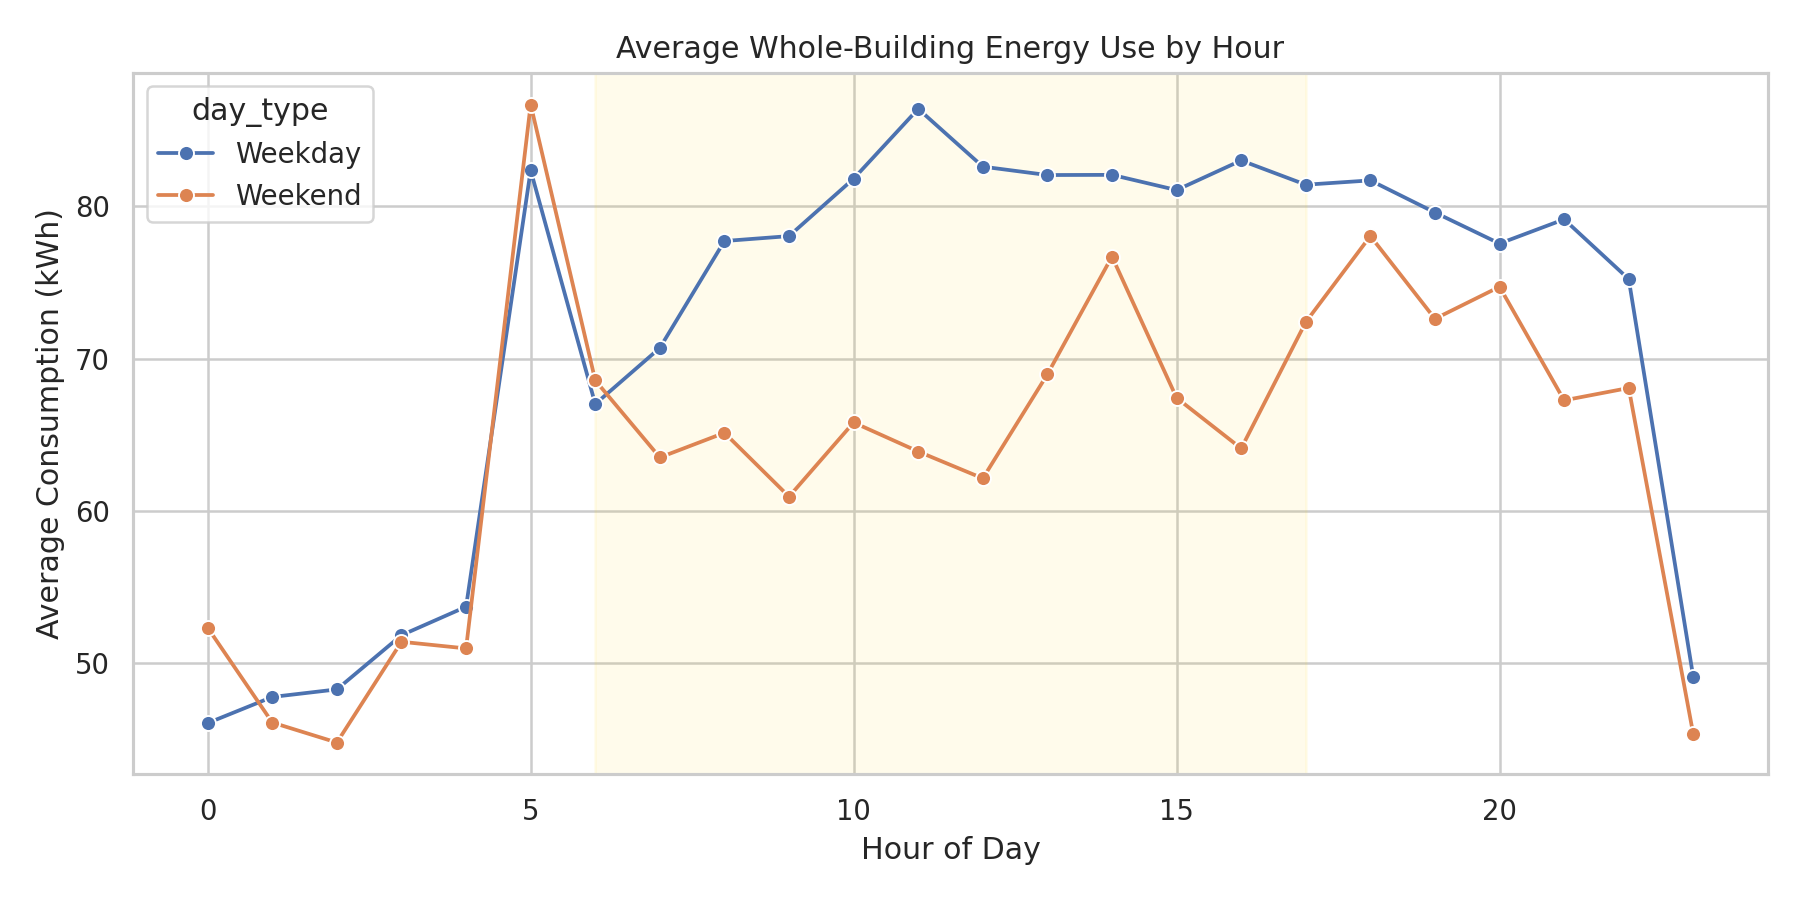

In [5]:
display(Markdown('### Average whole-building profile'))
display(Image(filename=str(FIGURE_DIR / 'whole_building_hourly_profile.png')))


## Room-Level Occupancy Signals

Rooms 354 and 361 now drive the main project objective. Room 354 provides VOC, temperature, CO2, and a `Noise Level` activity proxy, while Room 361 provides humidity, temperature, and CO2. Together, they show whether the revised occupancy objective is realistic with the current exports.


In [6]:
room_354 = load_room('354')
room_361 = load_room('361')

occupancy_signal_check = pd.DataFrame([
    {
        'room': '354',
        'voc_work_mean': room_354.loc[room_354['work_hours'], 'VOC_value'].mean(),
        'voc_off_mean': room_354.loc[~room_354['work_hours'], 'VOC_value'].mean(),
        'noise_work_mean': room_354.loc[room_354['work_hours'], 'Noise Level_value'].mean(),
        'noise_off_mean': room_354.loc[~room_354['work_hours'], 'Noise Level_value'].mean(),
        'temp_work_mean': room_354.loc[room_354['work_hours'], 'Zone Temp_value'].mean(),
        'temp_off_mean': room_354.loc[~room_354['work_hours'], 'Zone Temp_value'].mean(),
        'co2_gt_800_pct': (room_354['CO2_value'].dropna().gt(800).mean() * 100),
    },
    {
        'room': '361',
        'humidity_work_mean': room_361.loc[room_361['work_hours'], 'Zone Air Humid_value'].mean(),
        'humidity_off_mean': room_361.loc[~room_361['work_hours'], 'Zone Air Humid_value'].mean(),
        'temp_work_mean': room_361.loc[room_361['work_hours'], 'Zone Temp_value'].mean(),
        'temp_off_mean': room_361.loc[~room_361['work_hours'], 'Zone Temp_value'].mean(),
        'co2_gt_800_pct': (room_361['Zone CO2_value'].dropna().gt(800).mean() * 100),
    },
])
occupancy_signal_check


,room,voc_work_mean,voc_off_mean,noise_work_mean,noise_off_mean,temp_work_mean,temp_off_mean,co2_gt_800_pct,humidity_work_mean,humidity_off_mean
0,354,96.363593,74.230725,55.209351,54.246017,70.926358,69.655888,1.836807,NaN,NaN
1,361,NaN,NaN,NaN,NaN,69.900852,69.765551,0.035286,40.786966,39.686367


### Occupancy-oriented room signals

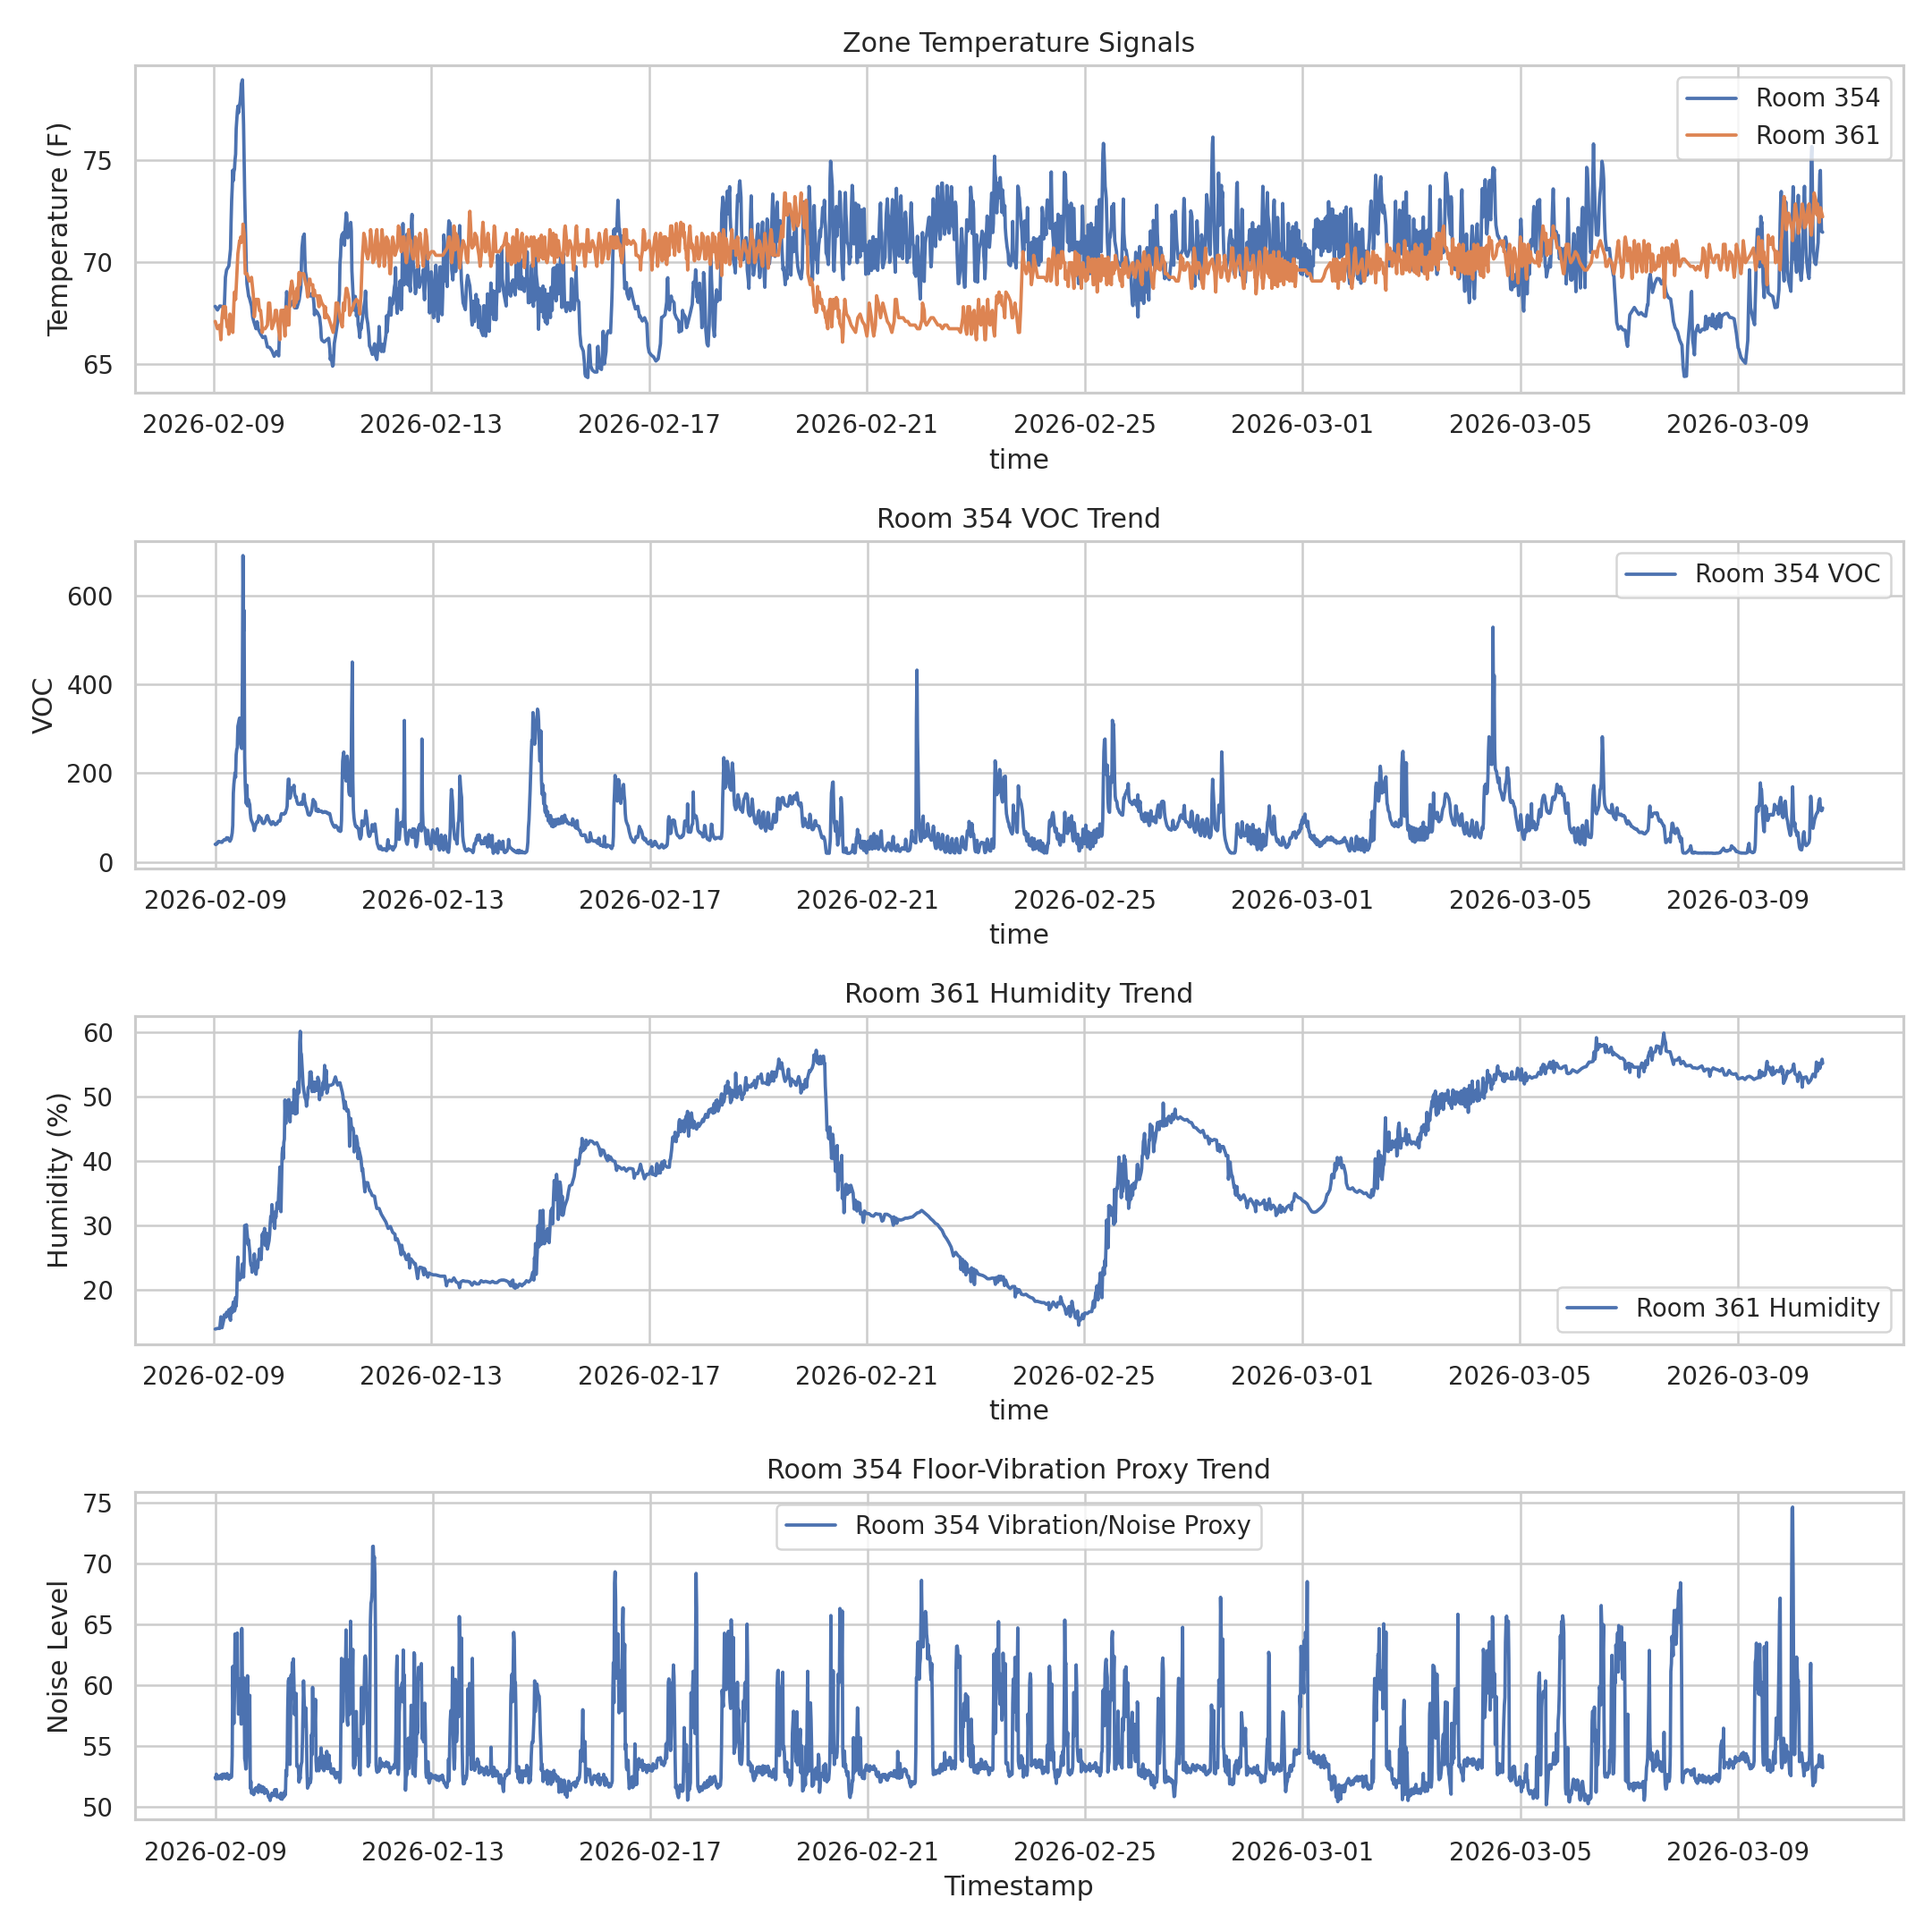

### Supporting room temperature and CO2 view

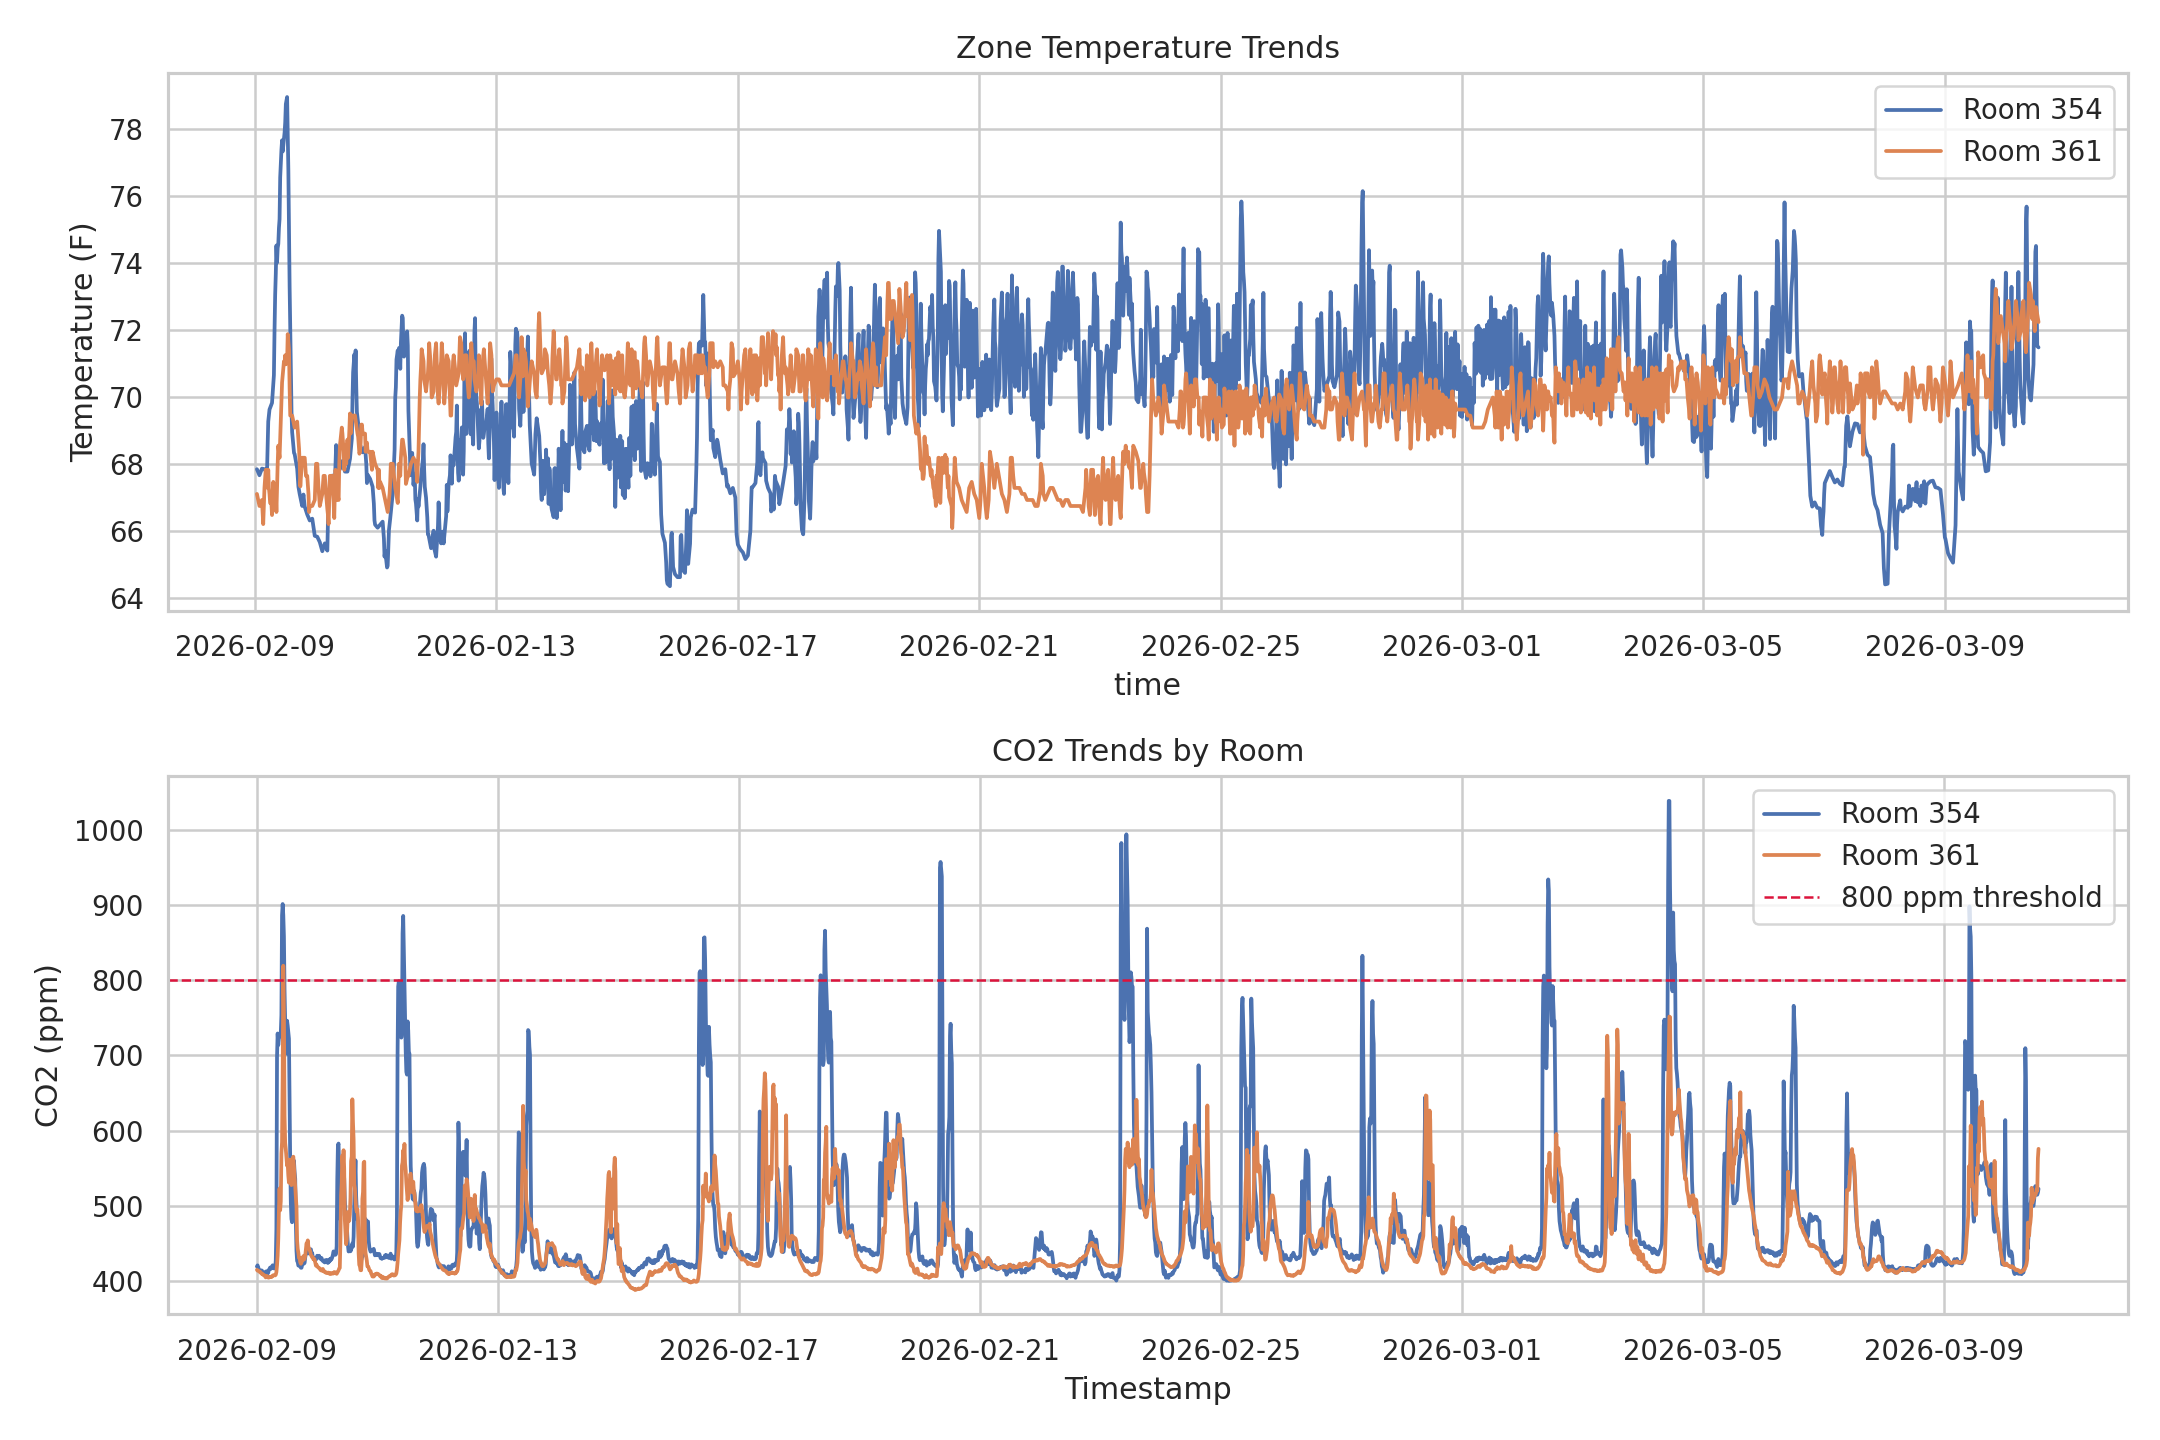

In [7]:
display(Markdown('### Occupancy-oriented room signals'))
display(Image(filename=str(FIGURE_DIR / 'room_occupancy_sensor_timeseries.png')))

display(Markdown('### Supporting room temperature and CO2 view'))
display(Image(filename=str(FIGURE_DIR / 'room_temperature_co2_timeseries.png')))


## AHU-Level Checks

The AHU figures are still helpful, but now mainly as supporting building context. They help explain operational differences across the building and show why room-level signals are a cleaner target for occupancy detection.


### AHU discharge temperature and CO2

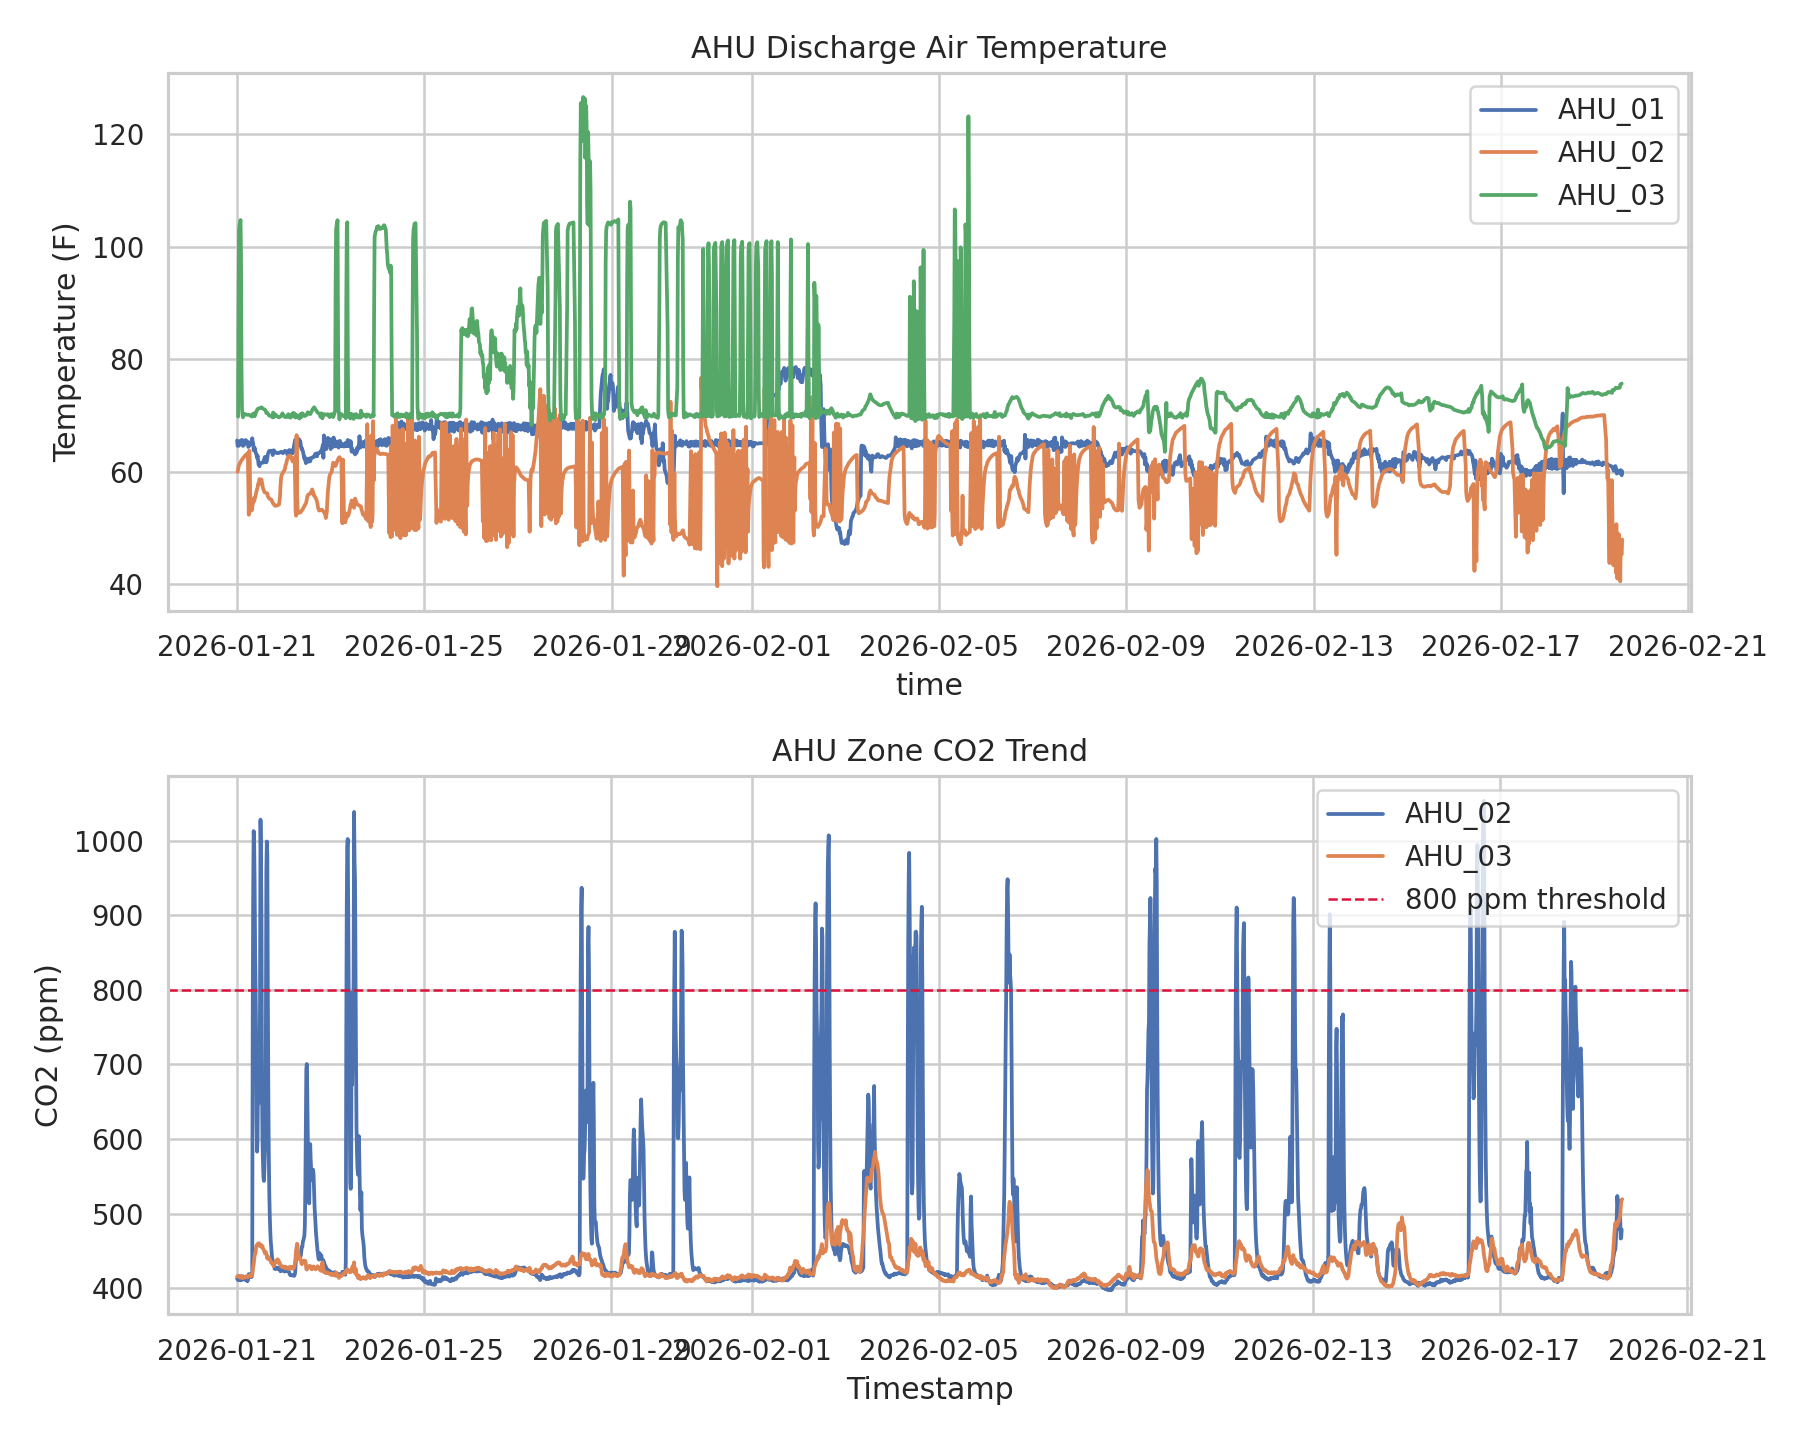

In [8]:
display(Markdown('### AHU discharge temperature and CO2'))
display(Image(filename=str(FIGURE_DIR / 'ahu_discharge_temp_and_co2.png')))


## Preliminary Interpretation

Current evidence supports the following draft conclusions:

- The initial EDA justified revising the project objective from broad HVAC efficiency review to occupancy detection.
- Room 354 provides the strongest immediate occupancy feature set because it already includes VOC, temperature, CO2, and the available activity proxy.
- Room 361 adds the humidity signal needed for the revised feature set, even though the current exports still split those features across rooms.
- Whole-building energy and AHU data remain useful supporting context, but the final model should be built around room-level occupancy signals.


In [9]:
json.loads(SUMMARY_PATH.read_text())


{'whole_building': {'start': '2026-01-29T00:00:00',
  'end': '2026-02-03T13:00:00',
  'records': 134,
  'work_hours_mean_kwh': 74.81,
  'off_hours_mean_kwh': 62.47,
  'weekday_mean_kwh': 71.34,
  'weekend_mean_kwh': 64.07,
  'peak_timestamp': '2026-02-02T16:00:00',
  'peak_kwh': 95.49},
 'rooms': [{'room': '354',
   'start': '2026-02-09T00:00:00',
   'end': '2026-03-10T13:30:00',
   'interval_count': 2839,
   'co2_mean': 480.27,
   'co2_max': 1038.68,
   'pct_co2_above_800': 1.84,
   'pct_co2_above_1000': 0.07,
   'temp_mean': 70.29,
   'temp_work_mean': 70.93,
   'temp_off_mean': 69.66,
   'temp_min': 64.35,
   'temp_max': 78.95,
   'voc_mean': 85.28,
   'voc_work_mean': 96.36,
   'voc_off_mean': 74.23,
   'voc_max': 689.21,
   'humidity_mean': None,
   'humidity_work_mean': None,
   'humidity_off_mean': None,
   'humidity_max': None,
   'noise_mean': 54.73,
   'noise_work_mean': 55.21,
   'noise_off_mean': 54.25,
   'noise_max': 74.62},
  {'room': '361',
   'start': '2026-02-09T00:00